# **Data Pre-Processing**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
dataset = pd.read_csv('SwedishMotorInsurance.csv')
dataset
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [4]:
dataset

,Kilometres,Zone,Bonus,Make,Insured,Claims,Payment
0,1,1,1,1,455.13,108,392491
1,1,1,1,2,69.17,19,46221
2,1,1,1,3,72.88,13,15694
3,1,1,1,4,1292.39,124,422201
4,1,1,1,5,191.01,40,119373
...,...,...,...,...,...,...,...
2177,5,7,7,5,8.74,0,0
2178,5,7,7,6,16.61,0,0
2179,5,7,7,7,2.83,1,966
2180,5,7,7,8,13.06,0,0


In [5]:
print(x)

[[  1.     1.     1.     1.   455.13 108.  ]
 [  1.     1.     1.     2.    69.17  19.  ]
 [  1.     1.     1.     3.    72.88  13.  ]
 ...
 [  5.     7.     7.     7.     2.83   1.  ]
 [  5.     7.     7.     8.    13.06   0.  ]
 [  5.     7.     7.     9.   384.87  16.  ]]


In [6]:
print(y)

[392491  46221  15694 ...    966      0 112252]


# **Filling Missing Data**

In [7]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(x[:, 1:3])
x[:, 1:3] = imputer.transform(x[:, 1:3])

In [8]:
print(x)

[[  1.     1.     1.     1.   455.13 108.  ]
 [  1.     1.     1.     2.    69.17  19.  ]
 [  1.     1.     1.     3.    72.88  13.  ]
 ...
 [  5.     7.     7.     7.     2.83   1.  ]
 [  5.     7.     7.     8.    13.06   0.  ]
 [  5.     7.     7.     9.   384.87  16.  ]]


In [9]:
print(y)

[392491  46221  15694 ...    966      0 112252]


# **Encoding**

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
x = np.array(ct.fit_transform(x))

In [11]:
print(x)

[[  1.     0.     0.   ...   1.   455.13 108.  ]
 [  1.     0.     0.   ...   2.    69.17  19.  ]
 [  1.     0.     0.   ...   3.    72.88  13.  ]
 ...
 [  0.     0.     0.   ...   7.     2.83   1.  ]
 [  0.     0.     0.   ...   8.    13.06   0.  ]
 [  0.     0.     0.   ...   9.   384.87  16.  ]]


In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [13]:
print(y)

[1515  881  559 ...   32    0 1208]


# **Training set and Test set**

In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [28]:
print(x_train)

[[1.000e+00 0.000e+00 0.000e+00 ... 5.000e+00 6.938e+01 1.300e+01]
 [0.000e+00 0.000e+00 0.000e+00 ... 9.000e+00 6.970e+01 2.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 5.000e+00 8.341e+01 8.000e+00]
 ...
 [0.000e+00 0.000e+00 1.000e+00 ... 8.000e+00 2.160e+03 5.500e+01]
 [0.000e+00 0.000e+00 1.000e+00 ... 1.000e+00 1.435e+01 0.000e+00]
 [0.000e+00 1.000e+00 0.000e+00 ... 8.000e+00 2.500e+00 0.000e+00]]


In [29]:
print(x_test)

[[  1.     0.     0.   ...   4.   160.66   8.  ]
 [  0.     1.     0.   ...   5.   149.71  15.  ]
 [  0.     0.     1.   ...   6.   113.33   2.  ]
 ...
 [  0.     1.     0.   ...   2.   358.55  22.  ]
 [  0.     1.     0.   ...   7.   240.77  23.  ]
 [  0.     0.     0.   ...   8.    65.8    1.  ]]


In [30]:
print(y_train)

[1111  721  693 ... 1506    0    0]


In [31]:
print(y_test)

[ 647  720  357 1414 1426 1516    0    0    0    0  285  392    0  179
    0    0 1074    0    0 1294   40    0  142  474 1636    0    0 1700
 1131    0 1304 1251 1647    0 1731  220  144  454  406    0    0   59
 1688    0  270 1167   68 1199 1563  697  177 1585   80    0  301  360
 1225    0 1130  604  873  606    0 1674  227  908    0  701  596    0
 1259 1349 1749    0 1740    0 1745  668    0  356 1709    0 1142  591
  565  410    0  517 1552    0 1510  241  156   20 1224   76  683  476
  429 1523 1361 1260  240  444  172 1729  994 1415 1343  327  956  999
    0  747  139    0  275 1051  332  691  386  499  181  707    0  317
    0 1540   67    0 1502    0 1093  334  726 1137  128  501  973 1300
  206  511 1035   96  583 1609  471  140 1083    0    0  949  737  864
   58  729    0 1212 1518 1155  197  555 1272   35  239 1641 1534 1437
 1368    0 1699  710  588 1218 1564    0 1591    0  381 1034  607  448
  978    0    0   79  872    0 1146 1479  202    0    0 1373  185 1207
 1409 

# **Feature Scaling**

In [32]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [33]:
print(x_train)

[[ 2.01444062 -0.50447316 -0.50715344 ...  0.00708344 -0.1971329
  -0.19758701]
 [-0.49641572 -0.50447316 -0.50715344 ...  1.55215971 -0.19706505
  -0.25759211]
 [-0.49641572 -0.50447316 -0.50715344 ...  0.00708344 -0.19415807
  -0.22486206]
 ...
 [-0.49641572 -0.50447316  1.97178984 ...  1.16589065  0.24614981
   0.03152339]
 [-0.49641572 -0.50447316  1.97178984 ... -1.53799283 -0.20880114
  -0.26850213]
 [-0.49641572  1.98226601 -0.50715344 ...  1.16589065 -0.21131374
  -0.26850213]]


In [34]:
print(x_test)

[[ 2.01444062 -0.50447316 -0.50715344 ... -0.37918562 -0.17777843
  -0.22486206]
 [-0.49641572  1.98226601 -0.50715344 ...  0.00708344 -0.18010021
  -0.18667699]
 [-0.49641572 -0.50447316  1.97178984 ...  0.39335251 -0.18781401
  -0.25759211]
 ...
 [-0.49641572  1.98226601 -0.50715344 ... -1.15172376 -0.13581901
  -0.14849192]
 [-0.49641572  1.98226601 -0.50715344 ...  0.77962158 -0.16079238
  -0.14303691]
 [-0.49641572 -0.50447316 -0.50715344 ...  1.16589065 -0.19789199
  -0.26304712]]


# **Visualization**

<Axes: >

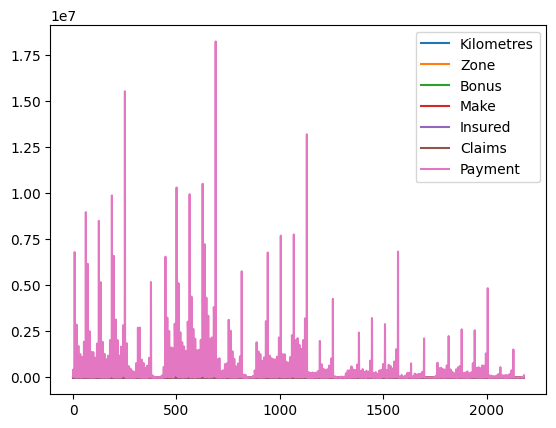

In [35]:
dataset.plot()

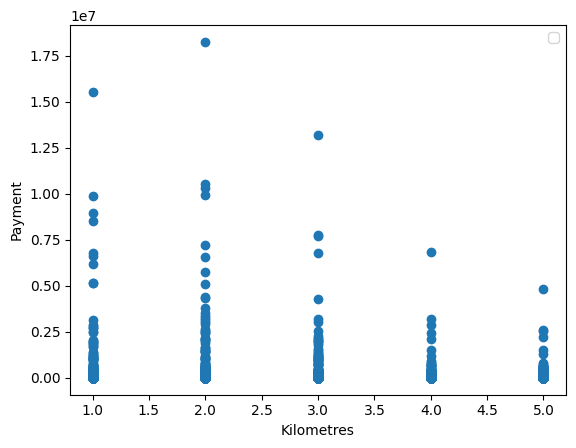

In [36]:
import matplotlib.pyplot as plt
plt.scatter(dataset['Kilometres'],dataset['Payment'])
plt.xlabel('Kilometres')
plt.ylabel('Payment')
plt.legend()
plt.show()

Kilometres       Axes(0.125,0.11;0.0945122x0.77)
Zone          Axes(0.238415,0.11;0.0945122x0.77)
Bonus         Axes(0.351829,0.11;0.0945122x0.77)
Make          Axes(0.465244,0.11;0.0945122x0.77)
Insured       Axes(0.578659,0.11;0.0945122x0.77)
Claims        Axes(0.692073,0.11;0.0945122x0.77)
Payment       Axes(0.805488,0.11;0.0945122x0.77)
dtype: object

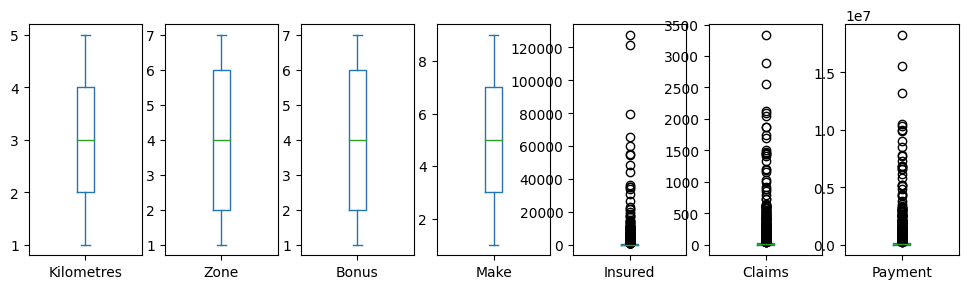

In [37]:
dataset.plot(kind='box', subplots=True, figsize=(12,3))

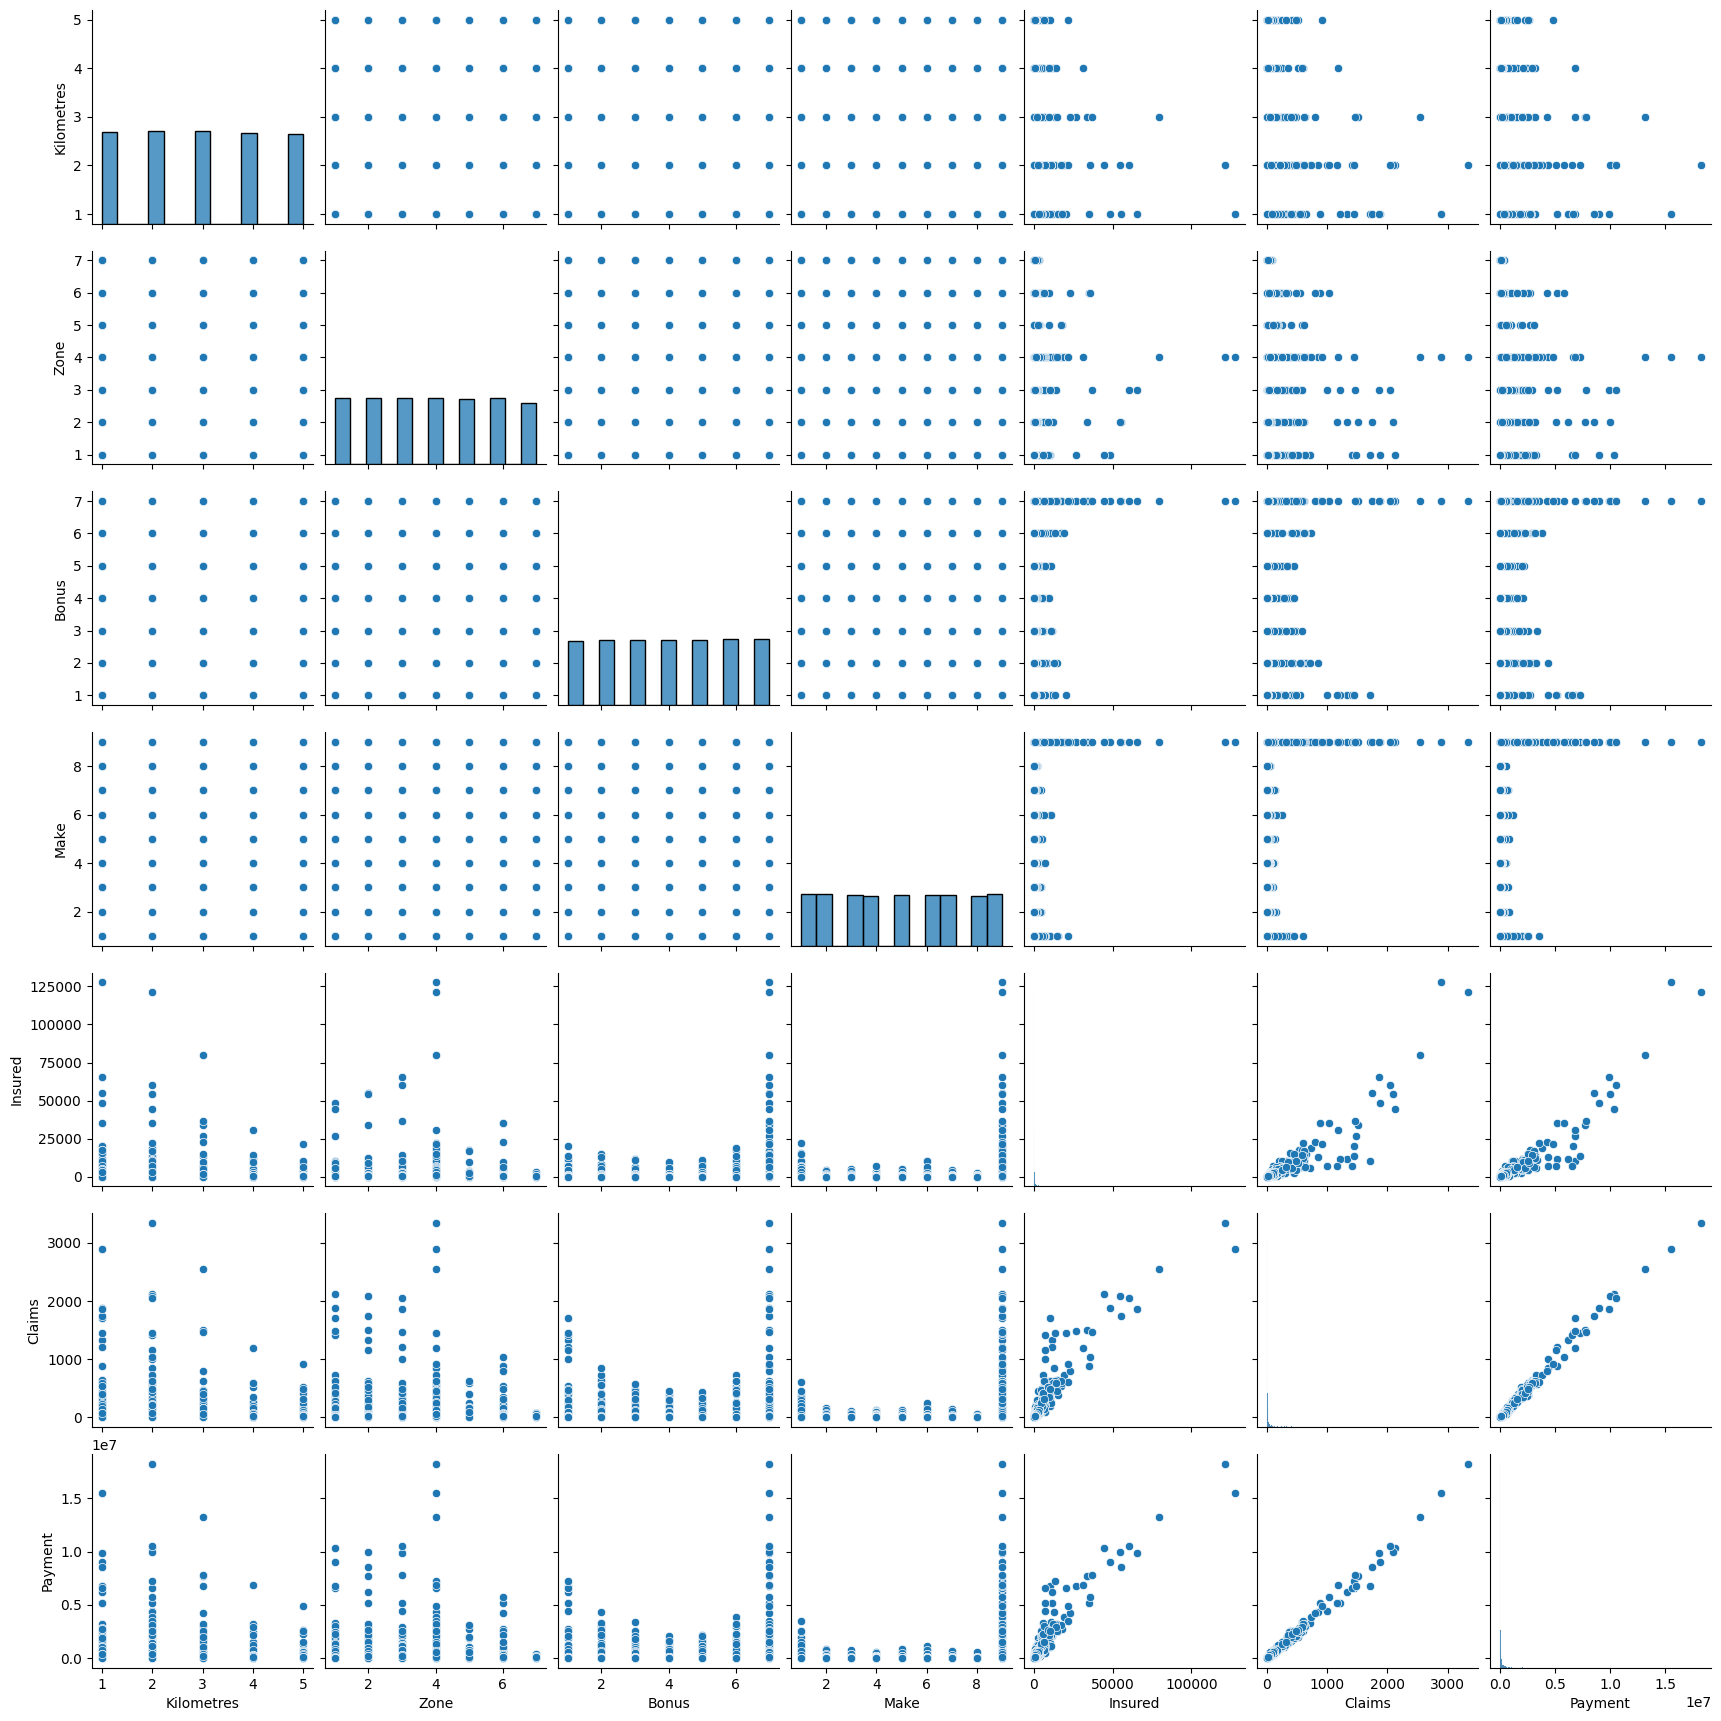

In [38]:
import seaborn as sns
sns.pairplot(dataset)

# **Linear Regression**

In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [40]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


In [41]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 205870.86555705982
R-squared: 0.3503228107610983


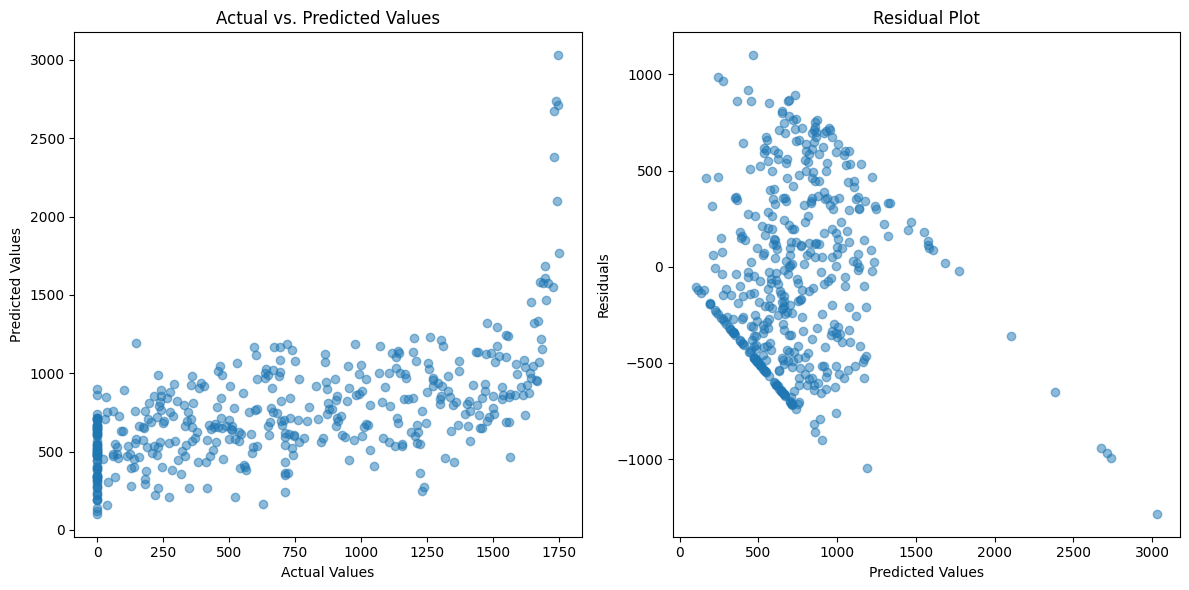

In [42]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.subplot(1, 2, 2)
plt.scatter(y_pred, y_test - y_pred, alpha=0.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()


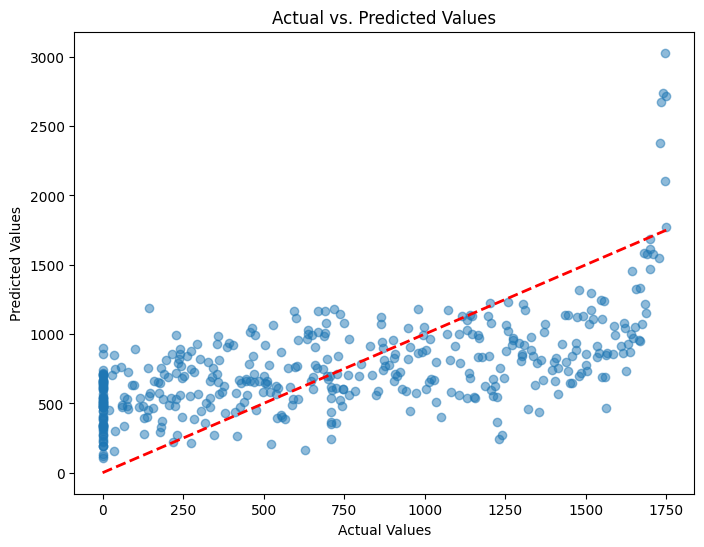

In [43]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.show()